# Z-Sampling Convergence Study — Au [110]

How does diffraction-pattern accuracy degrade as z-sampling becomes coarser?

- **Ground truth**: Second-Order Wave ODE with 128 slices/cell (finest z-sampling, tight tolerances)
- **Test methods**: Fresnel (Paraxial), Angular Spectrum (Non-Paraxial), WPM, Forward Square-Root Propagator
- **Input wave**: Plane wave
- **z-samplings**: 1, 2, 4, 8, 16, 32, 128 slices/cell
- **Metric**: Relative L2 norm of diffraction pattern difference vs Second-Order Wave ODE ground truth
- **Energy**: 200 keV, Au [110] zone axis, ~100 unit cells thick

In [1]:
%matplotlib inline

import os
from time import perf_counter
import functools

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".2"

import abtem
import cupy
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from ase.build import bulk, surface
from matplotlib.colors import LogNorm
from tqdm.auto import tqdm

from wide_angle_propagation.propagation_methods import (
    electron_refractive_index,
    energy2wavelength,
    fresnel_propagation_kernel,
    angular_spectrum_propagation_kernel,
    simulate_fresnel_as,
    simulate_wpm,
    simulate_kg_ode_full,
)
from wide_angle_propagation.propagation_methods import _lanczos_expsqrt

abtem.config.set({"device": "gpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)

## Build crystal and common objects

In [2]:
# --- Parameters ---
energy = 200e3
a_Au = 4.076

# --- Build Au [110] orthogonal cell ---
au_bulk = bulk("Au", "fcc", a=a_Au)
au_110 = surface(au_bulk, (1, 1, 0), layers=2)
unit_cell = abtem.orthogonalize_cell(au_110)

z_period = a_Au / np.sqrt(2)
unit_cell.cell[2, 2] = z_period
unit_cell.pbc = [True, True, True]

nx = int(np.ceil(10 / unit_cell.cell.lengths()[0]))
ny = int(np.ceil(10 / unit_cell.cell.lengths()[1]))
nz = int(np.ceil(100 / z_period))

supercell = unit_cell * (nx, ny, nz)
total_thickness = float(supercell.cell[2, 2])

wavelength = energy2wavelength(energy)
print(f"Au [110], {energy/1e3:.0f} keV, λ = {wavelength:.4f} Å")
print(f"Unit cell z-period = {z_period:.4f} Å")
print(f"Supercell: {nx}×{ny}×{nz}, total thickness = {total_thickness:.1f} Å")

# --- Z-sampling levels ---
slices_per_cell_list = [1, 2, 4, 8, 16, 32, 128]
dz_list = [z_period / s for s in slices_per_cell_list]

print(f"\n{'Slices/cell':>12s} {'dz (Å)':>10s} {'Total slices':>14s}")
print("-" * 38)
for spc, dz in zip(slices_per_cell_list, dz_list):
    n_sl = int(np.round(total_thickness / dz))
    print(f"{spc:>12d} {dz:>10.4f} {n_sl:>14d}")

Au [110], 200 keV, λ = 0.0251 Å
Unit cell z-period = 2.8822 Å
Supercell: 4×4×35, total thickness = 100.9 Å

 Slices/cell     dz (Å)   Total slices
--------------------------------------
           1     2.8822             35
           2     1.4411             70
           4     0.7205            140
           8     0.3603            280
          16     0.1801            560
          32     0.0901           1120
         128     0.0225           4480


## Forward Square-Root Propagator helper

In [3]:
def simulate_kg_fwd_lanczos(pot_arr, psi_0, dz, E, samp, lanczos_m=130):
    ny, nx = psi_0.shape
    k0_sq = (2 * jnp.pi / energy2wavelength(E)) ** 2
    dy, dx = samp
    fy = jnp.fft.fftfreq(ny, d=dy)
    fx = jnp.fft.fftfreq(nx, d=dx)
    Fx, Fy = jnp.meshgrid(fx, fy)
    kp_sq = (2 * jnp.pi * Fy) ** 2 + (2 * jnp.pi * Fx) ** 2
    n_sq_all = jax.vmap(lambda V: electron_refractive_index(V, E) ** 2)(pot_arr)
    probe_k = jnp.fft.fft2(jnp.asarray(psi_0, dtype=jnp.complex128)) / (ny * nx)
    state = probe_k.ravel()

    @functools.partial(jax.jit, static_argnums=(4, 5, 6))
    def _propagate_one_slice(s, n_sq, k0sq, kpsq, ny_, nx_, m_):
        def matvec(v):
            vg = v.reshape(ny_, nx_)
            conv = jnp.fft.fft2(n_sq * jnp.fft.ifft2(vg))
            return (k0sq * conv - kpsq * vg).ravel()
        return _lanczos_expsqrt(matvec, s, dz, m_)

    for i in range(pot_arr.shape[0]):
        state = _propagate_one_slice(state, n_sq_all[i], k0_sq, kp_sq, ny, nx, lanczos_m)

    exit_k = state.reshape(ny, nx)
    exit_wave = jnp.fft.ifft2(exit_k) * (ny * nx)
    return np.asarray(exit_wave)

print("Lanczos propagator defined.")

Lanczos propagator defined.


## Compute ground truth — KG ODE at 128 slices/cell

In [ ]:
ref_slices_per_cell = slices_per_cell_list[-1]  # 128
ref_dz = z_period / ref_slices_per_cell
ref_n_slices = int(np.round(total_thickness / ref_dz))

print(f"Ground truth: KG ODE, dz = {ref_dz:.4f} Å, {ref_n_slices} slices")
print("Building potential...")

pot_ref_abtem = abtem.Potential(
    supercell, sampling=0.1, slice_thickness=ref_dz,
    projection="finite", parametrization="lobato",
)
gpts = tuple(pot_ref_abtem.gpts)
sampling = (float(pot_ref_abtem.sampling[0]), float(pot_ref_abtem.sampling[1]))

pot_ref_gpu = pot_ref_abtem.build(lazy=False).array
pot_ref_arr = jnp.array(cupy.asnumpy(pot_ref_gpu) / ref_dz)
del pot_ref_gpu

ny, nx = pot_ref_arr.shape[1:]
probe_array = jnp.ones((ny, nx), dtype=jnp.complex128)

del pot_ref_abtem
cupy.get_default_memory_pool().free_all_blocks()

print(f"Grid: {gpts}, sampling = ({sampling[0]:.4f}, {sampling[1]:.4f}) Å")
print(f"Potential shape: {pot_ref_arr.shape}")
print(f"\nRunning KG ODE ground truth (rtol=1e-9, atol=1e-11)...")

t0 = perf_counter()
ew_gt, _, dp_gt_raw, _ = simulate_kg_ode_full(
    pot_ref_arr, probe_array, ref_dz, energy, sampling,
    rtol=1e-9, atol=1e-11,
)
dp_gt = np.abs(np.fft.fftshift(np.fft.fft2(np.asarray(ew_gt)))) ** 2
t_gt = perf_counter() - t0

del pot_ref_arr
print(f"Done in {t_gt:.1f}s, DP max: {dp_gt.max():.4e}")

Ground truth: KG ODE, dz = 0.0225 Å, 4480 slices
Building potential...
Grid: (116, 116), sampling = (0.0994, 0.0994) Å
Potential shape: (4480, 116, 116)

Running KG ODE ground truth (rtol=1e-9, atol=1e-11)...
Done in 129.7s, DP max: 6.6373e+07


## Sweep z-sampling for all 4 methods

For each slice thickness, rebuild the potential and run all methods.
Compare diffraction patterns against ground truth.

In [7]:
method_names = ["Fresnel MS", "Angular Spectrum MS", "WPM", "KG FWD"]

rel_l2_results = {name: [] for name in method_names}
rms_results = {name: [] for name in method_names}
timings = {name: [] for name in method_names}

for spc, dz in zip(slices_per_cell_list, dz_list):
    n_slices = int(np.round(total_thickness / dz))
    print(f"\n{'='*60}")
    print(f"dz = {dz:.4f} Å ({spc} slices/cell, {n_slices} total slices)")
    print(f"{'='*60}")

    pot_abtem = abtem.Potential(
        supercell, gpts=gpts, slice_thickness=dz,
        projection="finite", parametrization="lobato",
    )
    pot_gpu = pot_abtem.build(lazy=False).array
    pot_arr = jnp.array(cupy.asnumpy(pot_gpu) / dz)
    del pot_gpu
    del pot_abtem
    cupy.get_default_memory_pool().free_all_blocks()

    fk = jnp.array(fresnel_propagation_kernel(*gpts, sampling, z=dz, energy=energy))
    ak = jnp.array(angular_spectrum_propagation_kernel(*gpts, sampling, z=dz, energy=energy))

    methods_to_run = {
        "Fresnel MS":         lambda: simulate_fresnel_as(pot_arr, probe_array, fk, dz, energy),
        "Angular Spectrum MS": lambda: simulate_fresnel_as(pot_arr, probe_array, ak, dz, energy),
        "WPM":                lambda: simulate_wpm(pot_arr, probe_array, dz, energy, sampling),
        "KG FWD":             lambda: (simulate_kg_fwd_lanczos(pot_arr, probe_array, dz, energy, sampling), None, None),
    }

    for name in method_names:
        print(f"  {name}...", end=" ", flush=True)
        t0 = perf_counter()
        result = methods_to_run[name]()
        elapsed = perf_counter() - t0

        ew = np.asarray(result[0])
        dp = np.abs(np.fft.fftshift(np.fft.fft2(ew))) ** 2
        dp_diff = dp - dp_gt
        rel_l2 = float(np.linalg.norm(dp_diff) / np.linalg.norm(dp_gt))
        rms = float(np.sqrt(np.mean(dp_diff**2)))

        rel_l2_results[name].append(rel_l2)
        rms_results[name].append(rms)
        timings[name].append(elapsed)

        print(f"{elapsed:.1f}s, Rel L2 = {rel_l2:.4e}")

    del pot_arr, fk, ak
    cupy.get_default_memory_pool().free_all_blocks()

print(f"\n{'='*60}")
print("Sweep complete.")


dz = 2.8822 Å (1 slices/cell, 35 total slices)
  Fresnel MS... 0.2s, Rel L2 = 1.4937e-02
  Angular Spectrum MS... 0.2s, Rel L2 = 1.2438e-02
  WPM... 1.0s, Rel L2 = 1.2654e-02
  KG FWD... 1.3s, Rel L2 = 1.8192e-01

dz = 1.4411 Å (2 slices/cell, 70 total slices)
  Fresnel MS... 0.4s, Rel L2 = 3.3109e-02
  Angular Spectrum MS... 0.4s, Rel L2 = 3.3289e-02
  WPM... 1.9s, Rel L2 = 3.3833e-02
  KG FWD... 1.8s, Rel L2 = 1.4954e-01

dz = 0.7205 Å (4 slices/cell, 140 total slices)
  Fresnel MS... 0.9s, Rel L2 = 1.5954e-02
  Angular Spectrum MS... 0.9s, Rel L2 = 1.6898e-02
  WPM... 3.8s, Rel L2 = 1.7553e-02
  KG FWD... 2.8s, Rel L2 = 6.6387e-02

dz = 0.3603 Å (8 slices/cell, 280 total slices)
  Fresnel MS... 1.7s, Rel L2 = 2.0868e-02
  Angular Spectrum MS... 1.7s, Rel L2 = 1.2812e-02
  WPM... 7.6s, Rel L2 = 1.2919e-02
  KG FWD... 5.0s, Rel L2 = 1.1753e-02

dz = 0.1801 Å (16 slices/cell, 560 total slices)
  Fresnel MS... 3.4s, Rel L2 = 1.3059e-02
  Angular Spectrum MS... 3.4s, Rel L2 = 4.0454e-03

## Convergence plot

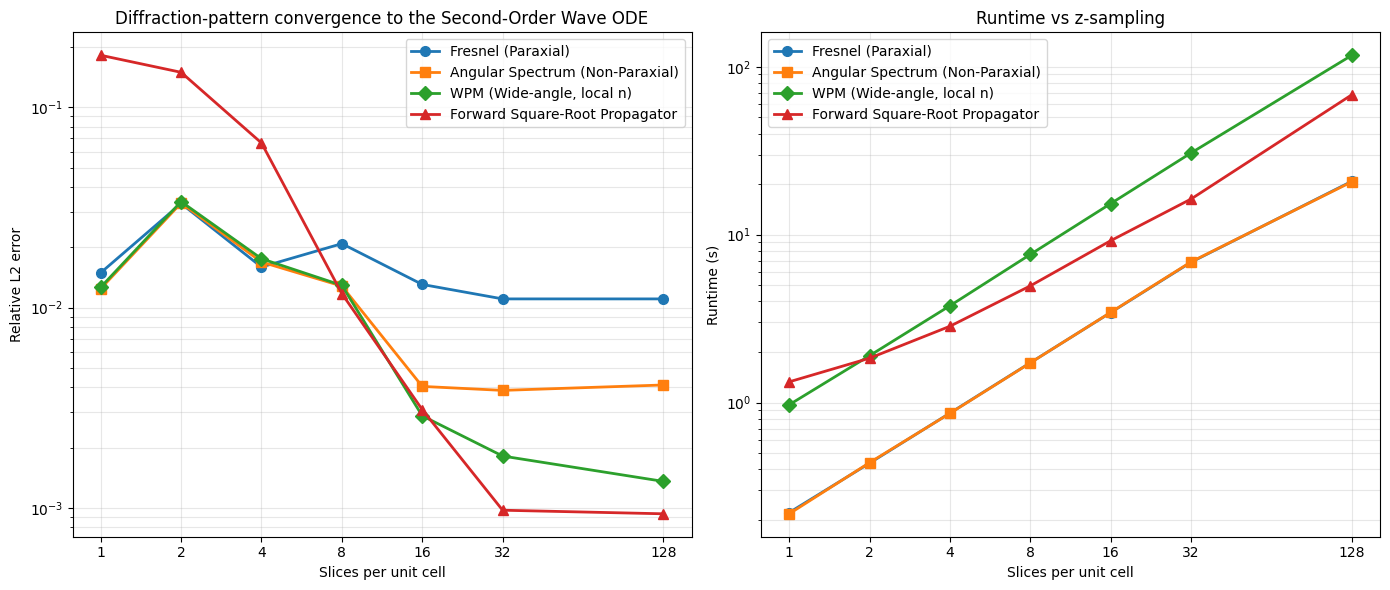

In [8]:
display_names = {
    "Fresnel MS": "Fresnel (Paraxial)",
    "Angular Spectrum MS": "Angular Spectrum (Non-Paraxial)",
    "WPM": "WPM (Wide-angle, local n)",
    "KG FWD": "Forward Square-Root Propagator",
}

colors = {
    "Fresnel MS": "C0",
    "Angular Spectrum MS": "C1",
    "WPM": "C2",
    "KG FWD": "C3",
}

markers = {
    "Fresnel MS": "o",
    "Angular Spectrum MS": "s",
    "WPM": "D",
    "KG FWD": "^",
}

spc_arr = np.array(slices_per_cell_list)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for name in method_names:
    display_name = display_names.get(name, name)
    ax1.plot(
        spc_arr,
        rel_l2_results[name],
        marker=markers[name],
        color=colors[name],
        linewidth=2,
        markersize=7,
        label=display_name,
    )
    ax2.plot(
        spc_arr,
        timings[name],
        marker=markers[name],
        color=colors[name],
        linewidth=2,
        markersize=7,
        label=display_name,
    )

for ax in (ax1, ax2):
    ax.set_xscale("log", base=2)
    ax.set_xticks(spc_arr)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.grid(True, which="both", alpha=0.3)

ax1.set_yscale("log")
ax1.set_xlabel("Slices per unit cell")
ax1.set_ylabel("Relative L2 error")
ax1.set_title("Diffraction-pattern convergence to the Second-Order Wave ODE")
ax1.legend()

ax2.set_yscale("log")
ax2.set_xlabel("Slices per unit cell")
ax2.set_ylabel("Runtime (s)")
ax2.set_title("Runtime vs z-sampling")
ax2.legend()

fig.tight_layout()

In [ ]:
# Export figure for paper
from pathlib import Path

def resolve_paper_fig_dir():
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        candidate = base / "Paper" / "figures"
        if candidate.parent.exists():
            candidate.mkdir(parents=True, exist_ok=True)
            return candidate
    raise FileNotFoundError("Could not locate Paper/figures from the current working directory")

paper_fig_dir = resolve_paper_fig_dir()
output_path = paper_fig_dir / "z_sampling_convergence.pdf"
fig.savefig(output_path, format="pdf", bbox_inches="tight", dpi=300)
if not output_path.exists() or output_path.stat().st_size == 0:
    raise RuntimeError(f"Failed to write figure: {output_path}")
print(f"Saved -> {output_path}")

Saved -> /home/dl277493/Documents/Code/WideAnglePropagation/Paper/figures/z_sampling_convergence.pdf


## Summary table

In [9]:
print(f"Au [110], {energy/1e3:.0f} keV, {total_thickness:.0f} Å")
print(f"Ground truth: KG ODE at dz = {ref_dz:.4f} Å ({ref_slices_per_cell} slices/cell)\n")

hdr = f"{'dz (Å)':>8s} {'sl/cell':>8s}"
for name in method_names:
    hdr += f" {name:>17s}"
print(hdr)
print("-" * len(hdr))

for i, (spc, dz) in enumerate(zip(slices_per_cell_list, dz_list)):
    row = f"{dz:>8.4f} {spc:>8d}"
    for name in method_names:
        row += f" {rel_l2_results[name][i]:>17.4e}"
    print(row)

Au [110], 200 keV, 101 Å
Ground truth: KG ODE at dz = 0.0225 Å (128 slices/cell)

  dz (Å)  sl/cell        Fresnel MS Angular Spectrum MS               WPM            KG FWD
-------------------------------------------------------------------------------------------
  2.8822        1        1.4937e-02        1.2438e-02        1.2654e-02        1.8192e-01
  1.4411        2        3.3109e-02        3.3289e-02        3.3833e-02        1.4954e-01
  0.7205        4        1.5954e-02        1.6898e-02        1.7553e-02        6.6387e-02
  0.3603        8        2.0868e-02        1.2812e-02        1.2919e-02        1.1753e-02
  0.1801       16        1.3059e-02        4.0454e-03        2.8839e-03        3.0980e-03
  0.0901       32        1.1059e-02        3.8645e-03        1.8172e-03        9.7483e-04
  0.0225      128        1.1059e-02        4.1121e-03        1.3577e-03        9.3557e-04
